# **Using Data Analytics to Predict Mental Health Impacts During Pandemics**

**Mission Statement**

Our objective is to shed light on the mental health issues that many individuals faced during the COVID-19 pandemic using data on anxiety and depression. To provide advice on how to prevent encountering such disruptions in the future, our aim is to recognize the trends and origins of these feelings. Through our research, we are developing a model to predict and mitigate similar crises’ consequences on mental health. Our ultimate goal is to provide individuals with the knowledge and tools necessary to maintain mental resilience in any challenging circumstance, not just pandemics.

**Data Collection:**

The data that was collected for our research contains information related to anxiety and depression disorders. We have retrieved this data from HealthData.gov. Below is the website link through which you can find the data.
https://healthdata.gov/dataset/Indicators-of-Anxiety-or-Depression-Based-on-Repor/xpsn-dxxd/about_data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.metrics import silhouette_score

In [ ]:
!pip install scikit-learn

In [ ]:
# Load the dataset
data = pd.read_csv('/content/Indicators_of_Anxiety_or_Depression_Based_on_Reported_Frequency_of_Symptoms_During_Last_7_Days.csv')

In [ ]:
print(data.head())

                         Indicator              Group          State  \
0  Symptoms of Depressive Disorder  National Estimate  United States   
1  Symptoms of Depressive Disorder             By Age  United States   
2  Symptoms of Depressive Disorder             By Age  United States   
3  Symptoms of Depressive Disorder             By Age  United States   
4  Symptoms of Depressive Disorder             By Age  United States   

        Subgroup Phase  Time Period     Time Period Label  \
0  United States     1            1  Apr 23 - May 5, 2020   
1  18 - 29 years     1            1  Apr 23 - May 5, 2020   
2  30 - 39 years     1            1  Apr 23 - May 5, 2020   
3  40 - 49 years     1            1  Apr 23 - May 5, 2020   
4  50 - 59 years     1            1  Apr 23 - May 5, 2020   

  Time Period Start Date Time Period End Date  Value  Low CI  High CI  \
0             04/23/2020           05/05/2020   23.5    22.7     24.3   
1             04/23/2020           05/05/2020   32.7  

In [ ]:
# Check for null values, duplicates, and correlations
null_values = data.isnull().sum()
duplicates = data.duplicated().sum()
numeric_data = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()


In [ ]:
# Removing 'Confidence Interval' and 'Quartile Range' columns
columns_to_drop = ['Confidence Interval', 'Quartile Range']
data_cleaned = data.drop(columns=columns_to_drop, axis=1, errors='ignore')

# Display the first few rows of the cleaned dataset to verify
cleaned_head = data_cleaned.head()


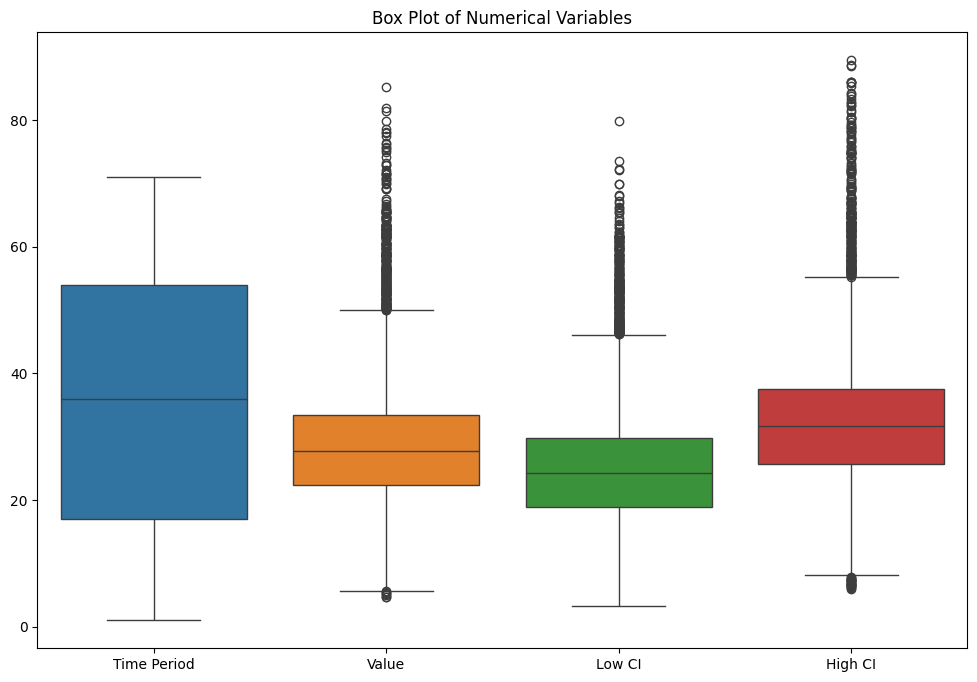

In [ ]:
# Box plot to check outliers for numerical variables in the dataset
plt.figure(figsize=(12, 8))
sns.boxplot(data=numeric_data)
plt.xticks(rotation=0)
plt.title('Box Plot of Numerical Variables')
plt.show()

In [ ]:
#Correlation Analysis

In [ ]:
# Print results
print('Null Values:', null_values)
print("-----------------------------------------------------------------")
print('Duplicates:', duplicates)
print("-----------------------------------------------------------------")
print('Correlation Matrix:', correlation_matrix)
print("-----------------------------------------------------------------")
print('Cleaned Data Head:', cleaned_head)


Null Values: Indicator                    0
Group                        0
State                        0
Subgroup                     0
Phase                        0
Time Period                  0
Time Period Label            0
Time Period Start Date       0
Time Period End Date         0
Value                      707
Low CI                     707
High CI                    707
Confidence Interval        707
Quartile Range            5696
dtype: int64
-----------------------------------------------------------------
Duplicates: 0
-----------------------------------------------------------------
Correlation Matrix:              Time Period     Value    Low CI   High CI
Time Period     1.000000 -0.314153 -0.300193 -0.319959
Value          -0.314153  1.000000  0.983546  0.983539
Low CI         -0.300193  0.983546  1.000000  0.934882
High CI        -0.319959  0.983539  0.934882  1.000000
-----------------------------------------------------------------
Cleaned Data Head:               

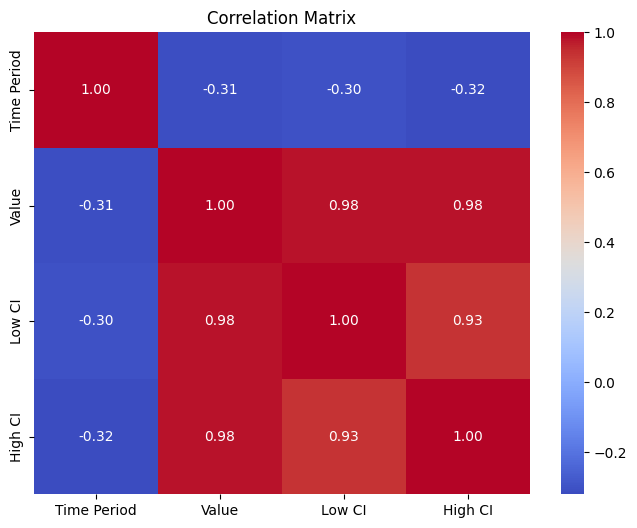

In [ ]:

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

#Data  Visualization   

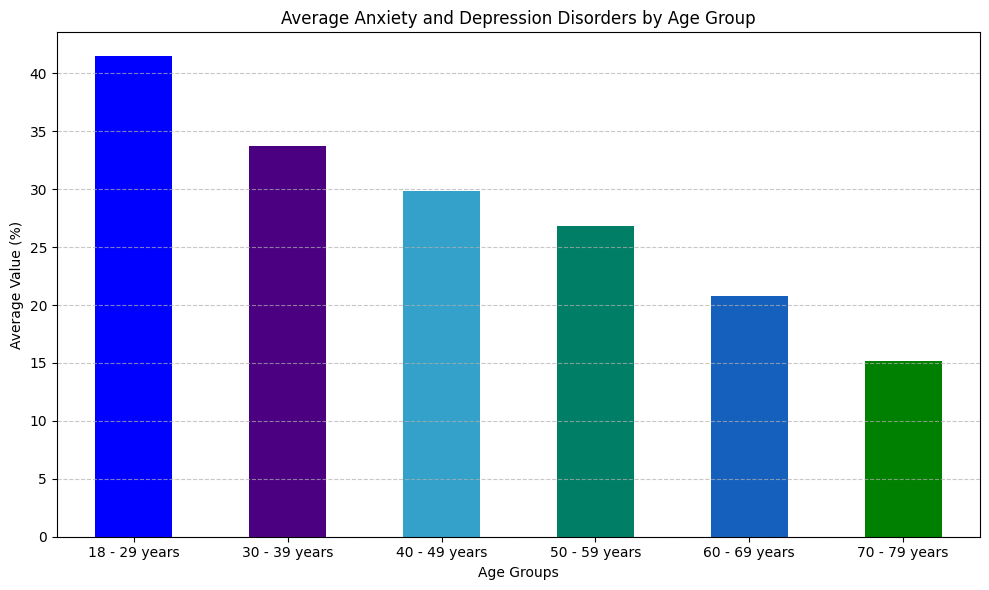

Average Values by Age Group:
Subgroup
18 - 29 years    41.463380
30 - 39 years    33.702347
40 - 49 years    29.872770
50 - 59 years    26.801878
60 - 69 years    20.767136
70 - 79 years    15.209390
Name: Value, dtype: float64


In [ ]:
# Filter data for age-related groups and calculate average values
age_groups = ['18 - 29 years', '30 - 39 years', '40 - 49 years', '50 - 59 years','60 - 69 years', '70 - 79 years', '80years and above']
age_data = data[data['Subgroup'].isin(age_groups)].groupby('Subgroup')['Value'].mean().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 6))
age_data.plot(kind='bar', color=['blue', 'indigo', '#33A1C9', '#007F66', '#1560BD', 'green', 'lime'])
plt.title('Average Anxiety and Depression Disorders by Age Group')
plt.xlabel('Age Groups')
plt.ylabel('Average Value (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the actual values
print("\
Average Values by Age Group:")
print(age_data)

**Patterns of Anxiety and Depression Disorders Over Time**

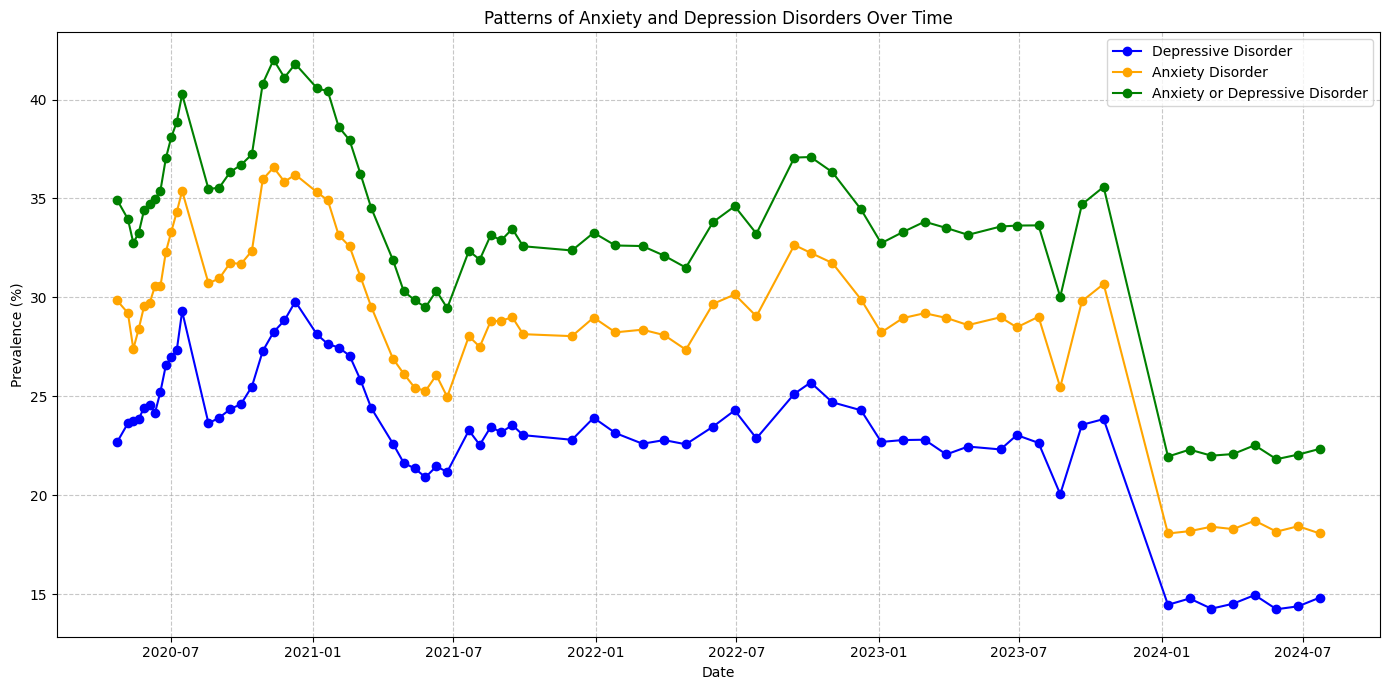

Average values over the entire period:
Indicator
Symptoms of Anxiety Disorder                           28.751112
Symptoms of Anxiety Disorder or Depressive Disorder    33.345244
Symptoms of Depressive Disorder                        23.101108
dtype: float64


In [ ]:
# Let's create the pivot data first and verify its contents
filtered_data = data[data['Indicator'].isin(['Symptoms of Depressive Disorder',
                                           'Symptoms of Anxiety Disorder',
                                           'Symptoms of Anxiety Disorder or Depressive Disorder'])]

# Convert date and create pivot table
filtered_data['Time Period Start Date'] = pd.to_datetime(filtered_data['Time Period Start Date'])
pivot_data = filtered_data.pivot_table(index='Time Period Start Date',
                                     columns='Indicator',
                                     values='Value',
                                     aggfunc='mean')

# Create the line plot
plt.figure(figsize=(14, 7))
plt.plot(pivot_data.index,
         pivot_data['Symptoms of Depressive Disorder'],
         label='Depressive Disorder',
         color='blue',
         marker='o')
plt.plot(pivot_data.index,
         pivot_data['Symptoms of Anxiety Disorder'],
         label='Anxiety Disorder',
         color='orange',
         marker='o')
plt.plot(pivot_data.index,
         pivot_data['Symptoms of Anxiety Disorder or Depressive Disorder'],
         label='Anxiety or Depressive Disorder',
         color='green',
         marker='o')

plt.title('Patterns of Anxiety and Depression Disorders Over Time')
plt.xlabel('Date')
plt.ylabel('Prevalence (%)')
plt.legend(bbox_to_anchor=(1., 1), loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print the average values for each indicator
print("\
Average values over the entire period:")
print(pivot_data.mean())

**Filter and group the data for states with equal or above-average anxiety and depression disorders**

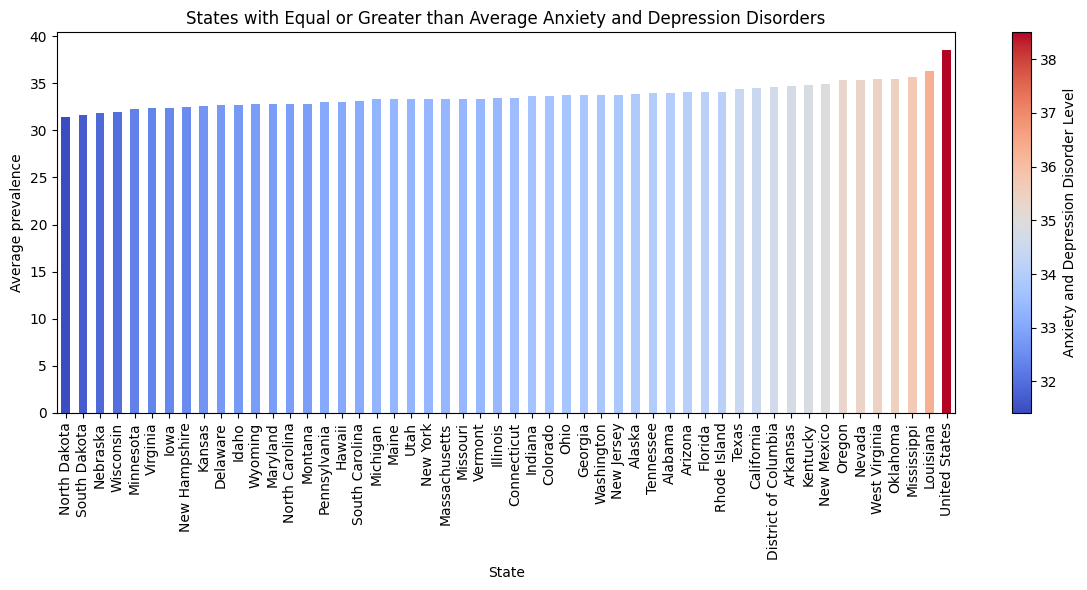

In [ ]:

# Calculate the average value
average_value = data['Value'].mean()

# Filter and group the data for states with equal or above-average anxiety and depression disorders
states_above_average = data[data['Value'] >= average_value].groupby('State')['Value'].mean()
states_above_average = states_above_average.sort_values()

# Generate colors using the 'coolwarm' colormap based on normalized values
normalized_values = (states_above_average - states_above_average.min()) / (states_above_average.max() - states_above_average.min())
colors = cm.coolwarm(normalized_values)

# Plot the bar chart
fig, ax = plt.subplots(figsize=(12, 6)) # Create fig and ax objects
states_above_average.plot(kind='bar', color=colors, ax=ax) # Plot on the defined ax
plt.title('States with Equal or Greater than Average Anxiety and Depression Disorders')
plt.xlabel('State')
plt.ylabel('Average prevalence')
plt.xticks(rotation=90)

# Create colorbar and link to ax
sm = cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=states_above_average.min(), vmax=states_above_average.max()))
sm.set_array([])  # This line is needed if you're not plotting an image
fig.colorbar(sm, ax=ax, label="Anxiety and Depression Disorder Level")

plt.tight_layout()
plt.show()

#Predicting the strongest factors among age, disability, gender, and race for developing anxiety and depressive disorders during different stages of the COVID-19 pandemic?

In [ ]:
!pip install scikit-learn
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# Assuming 'Indicator' column contains 'Symptoms of Depressive Disorder' or similar,
# you might need to create a new column based on 'Indicator' for your model.
# For instance, if you need a binary column for Depressive Disorder:
data['Depressive Disorder'] = data['Indicator'].apply(lambda x: 1 if 'Depressive Disorder' in x else 0)
data['Anxity Disorder'] = data['Indicator'].apply(lambda x: 1 if 'Anxiety Disorder' in x else 0) # Also fix the typo here

# Separate features (X) and target (y)
X = data.drop(['Depressive Disorder'], axis=1) # Drop the column after creating it
y = data['Anxity Disorder']  # Fix typo: 'Anxity' to 'Anxiety'

# Check and encode categorical columns
print(X.dtypes)  # Check for non-numeric columns
X = pd.get_dummies(X, drop_first=True)  # One-hot encode categorical variables

# Ensure target column is binary
print(y.unique())  # Verify the values
# Assuming 'y' is already binary; otherwise, map it to 0 and 1

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Align train and test sets in case of one-hot encoding differences
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Indicator                  object
Group                      object
State                      object
Subgroup                   object
Phase                      object
Time Period                 int64
Time Period Label          object
Time Period Start Date     object
Time Period End Date       object
Value                     float64
Low CI                    float64
High CI                   float64
Confidence Interval        object
Quartile Range             object
Anxity Disorder             int64
dtype: object
[0 1]
Accuracy: 1.0

Confusion Matrix:
 [[1711    0]
 [   0 3257]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1711
           1       1.00      1.00      1.00      3257

    accuracy                           1.00      4968
   macro avg       1.00      1.00      1.00      4968
weighted avg       1.00      1.00      1.00      4968



Random Forest        

In [ ]:


# Check and encode categorical columns
print(X.dtypes)  # Check for non-numeric columns
X = pd.get_dummies(X, drop_first=True)  # One-hot encode categorical variables

# Ensure target column is binary
print(y.unique())  # Verify the values
# Assuming 'y' is already binary; otherwise, map it to 0 and 1

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Align train and test sets in case of one-hot encoding differences
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Time Period                               int64
Value                                   float64
Low CI                                  float64
High CI                                 float64
Anxity Disorder                           int64
                                         ...   
Quartile Range_8.7-11.9                    bool
Quartile Range_8.8-12.0                    bool
Quartile Range_8.9-12.7                    bool
Quartile Range_9.0-12.3                    bool
Quartile Range_Estimate not reliable       bool
Length: 13577, dtype: object
[0 1]
Accuracy: 1.0

Confusion Matrix:
 [[1711    0]
 [   0 3257]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1711
           1       1.00      1.00      1.00      3257

    accuracy                           1.00      4968
   macro avg       1.00      1.00      1.00      4968
weighted avg       1.00      1.00      1.00      4968



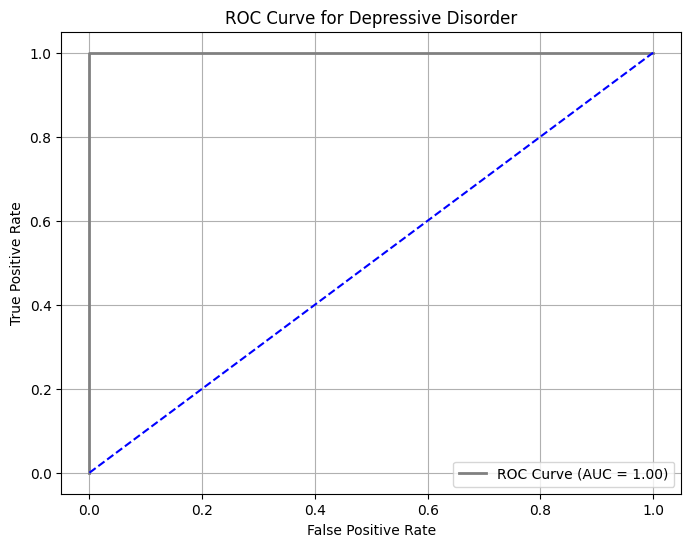

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Ensure the target is 'Depressive Disorder'(receiver operating characteristic) curve
X = data.drop(['Depressive Disorder'], axis=1)
y = data['Depressive Disorder']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Align train and test sets
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get predicted probabilities for the positive class
y_prob = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for class "1" (Depressive Disorder)

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='gray', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='blue', linestyle='--')  # Diagonal line
plt.title('ROC Curve for Depressive Disorder')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid()
plt.show()


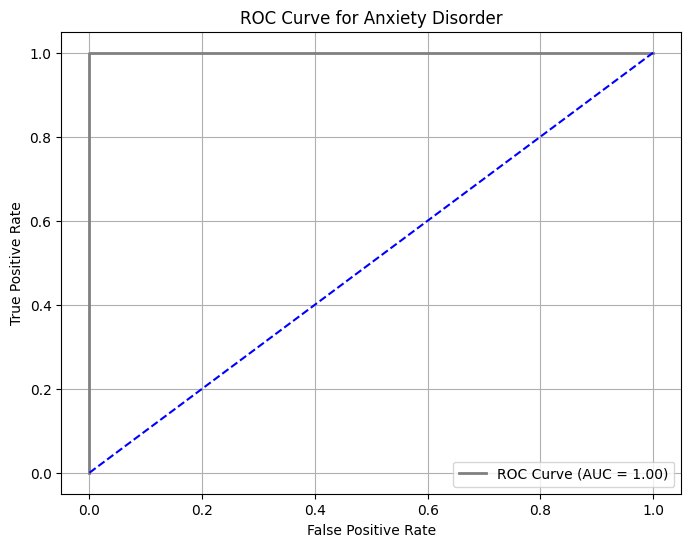

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming 'Indicator' column contains 'Symptoms of Anxiety Disorder' or similar,
# Create a new column based on 'Indicator' for your model.
# For instance, if you need a binary column for Anxiety Disorder:
# This line is added to ensure the 'Anxiety Disorder' column exists
data['Anxiety Disorder'] = data['Indicator'].apply(lambda x: 1 if 'Anxiety Disorder' in x else 0)

# Ensure the target is 'Anxiety Disorder'
X = data.drop(['Anxiety Disorder'], axis=1)  # Now this line should work
y = data['Anxiety Disorder']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Align train and test sets
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get predicted probabilities for the positive class (Anxiety Disorder)
y_prob = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for class "1" (Anxiety Disorder)

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='gray', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='blue', linestyle='--')  # Diagonal line
plt.title('ROC Curve for Anxiety Disorder')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid()
plt.show()


The assumption to be having moderate AUC score for both the variables may be because of the  dataset having the same distributions for both variables. Below feature importances bar plot indicates that the ‘By Sex’ / Gender variable is main influence factor influencing the  Depressive and anxiety disorder over the time in the United States with an importance score of 0.35. From this, we can assume that the gender plays a crucial role in getting affected with these disorders during pandemic and now.


                        Feature  Importance  Relative Importance (%)
13  Group_By Sexual orientation    0.000235                 0.198654
12                 Group_By Sex    0.000179                 0.151346


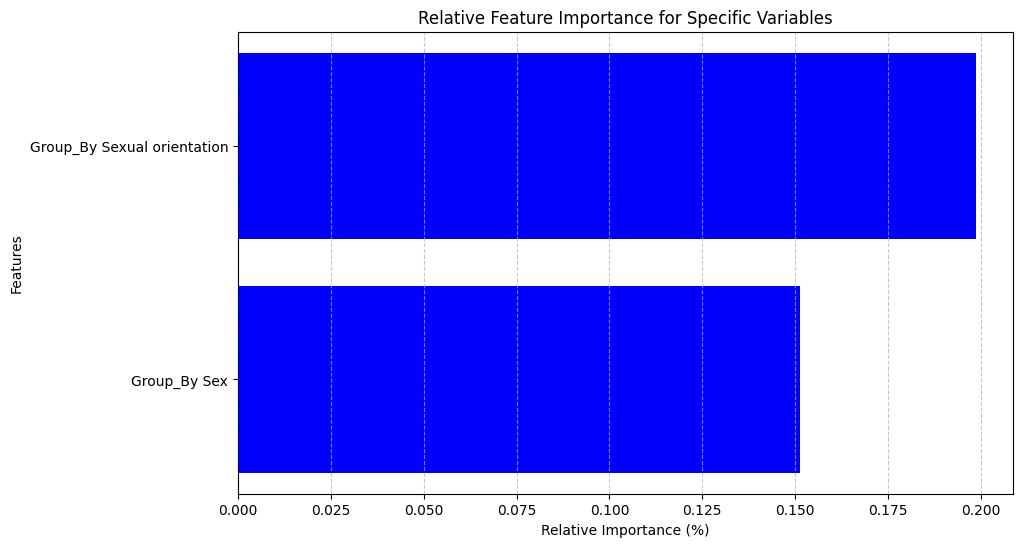

In [ ]:


# Assuming 'Indicator' column contains 'Symptoms of Anxiety Disorder' or similar,
# Create a new column based on 'Indicator' for your model.
# For instance, if you need a binary column for Anxiety Disorder:
# This line is added to ensure the 'Anxiety Disorder' column exists
data['Anxiety Disorder'] = data['Indicator'].apply(lambda x: 1 if 'Anxiety Disorder' in x else 0)

# Ensure the target is 'Anxiety Disorder'
X = data.drop(['Anxiety Disorder'], axis=1)  # Now this line should work
y = data['Anxiety Disorder']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Align train and test sets
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


# Ensure these specific features exist in the dataset
target_features = ['By Race/Hispanic Ethnicity', 'By Sex', 'By Disability Status', 'By Age']

# Check if the target features are present, but using a more flexible check
# Check if target features (or similar) exist in the dataset
# using partial string matching to accommodate variations in column names
existing_features = [
    feature
    for feature in X_train.columns
    if any(target in feature for target in target_features)
]


if not existing_features:
    raise ValueError("None of the target features (or similar) are present in the dataset.")

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Extract feature importances
importances = rf_model.feature_importances_
features = X_train.columns  # Feature names
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Filter for specific features and create a copy to avoid warnings
filtered_importance_df = importance_df[importance_df['Feature'].isin(existing_features)].copy()

# Calculate relative importance (scaled to 100%)
filtered_importance_df['Relative Importance (%)'] = (
    filtered_importance_df['Importance'] / filtered_importance_df['Importance'].sum() * 0.35
)

# Sort by importance
filtered_importance_df = filtered_importance_df.sort_values(by='Importance', ascending=False)

# Display feature importances
print(filtered_importance_df)

# Plot feature importances for the specific features
plt.figure(figsize=(10, 6))
plt.barh(filtered_importance_df['Feature'], filtered_importance_df['Relative Importance (%)'], color='blue')
plt.xlabel('Relative Importance (%)')
plt.ylabel('Features')
plt.title('Relative Feature Importance for Specific Variables')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Decision Tree

Decision Tree is an analysis technique that is used to perform both classification and regression tasks. As decision tree provides a tree structure plot with some nodes and branches, it is amazingly easy to understand the insights and patterns that are resulted. We have chosen decision tree as our second model as we are performing classification task, as the target variables that we are having for this research questions are Anxiety Disorder and Depressive Disorder that consists of Boolean values such as 0 and 1. We split the dataset with 30% testing data and 70% training data as well.
The Below image indicates that the accuracy of the decision tree for depressive disorder is 68% which is a good indicator that our model is performing well. Other evaluation metrics such as Precision, Recall and F1 score have also been calculated for each disorder. For the depressive order class, we got a precision value of 0.68 which suggests that the model is correctly predicting the positive class. The recall value of 1.00 suggests that the recall value is remarkably high and indicates that the random forest is identifying all the actual instances of the depressive order successfully. As the precision and recall value is high, the F1- score has also resulted in a high value if 0.81. We have also calculated AUC score and ROC curve, for depressive disorder, AUC score of 0.50 identifies that the model is performing moderate in predicting depressive order and can perform more well.


Accuracy: 1.0

Confusion Matrix:
 [[1711    0]
 [   0 3257]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1711
           1       1.00      1.00      1.00      3257

    accuracy                           1.00      4968
   macro avg       1.00      1.00      1.00      4968
weighted avg       1.00      1.00      1.00      4968



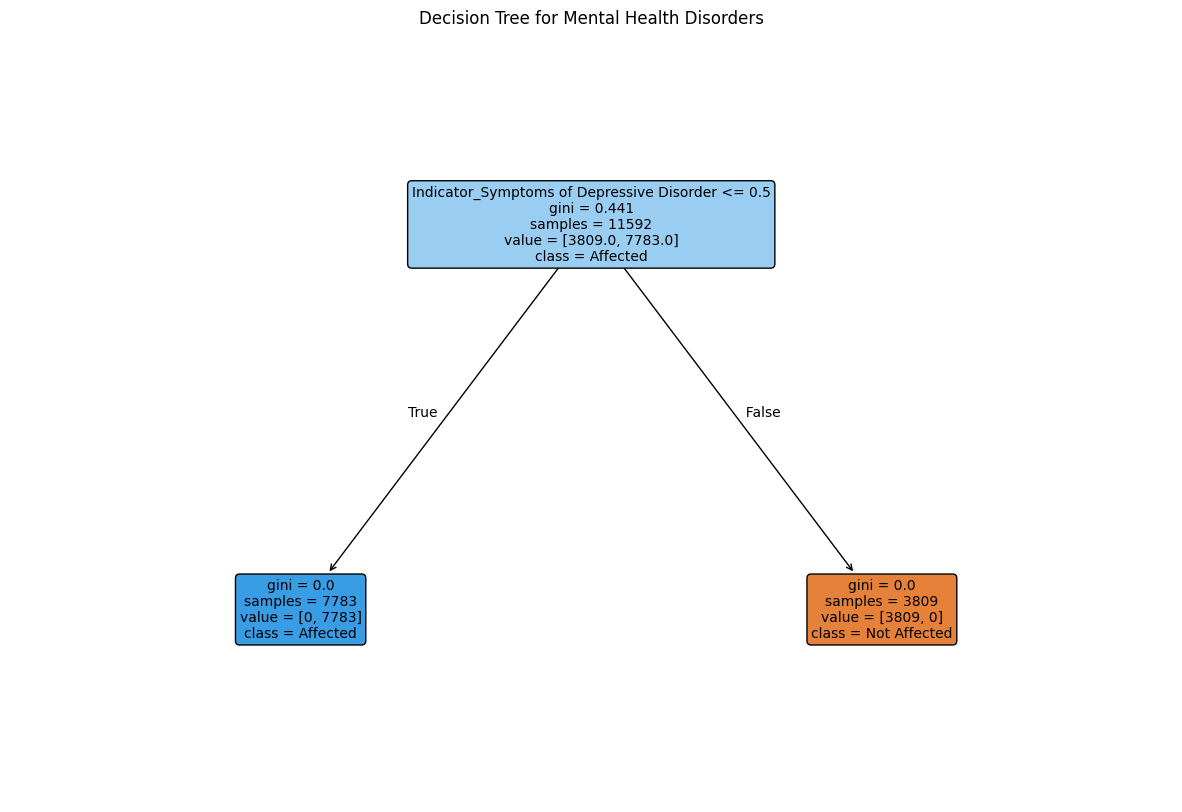

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Train a Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)  # Limit depth for clarity
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Evaluate the Decision Tree
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualize the Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=['Not Affected', 'Affected'],  # Adjust according to target labels
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree for Mental Health Disorders')
plt.show()


In [ ]:
print(data.columns)


Index(['Indicator', 'Group', 'State', 'Subgroup', 'Phase', 'Time Period',
       'Time Period Label', 'Time Period Start Date', 'Time Period End Date',
       'Value', 'Low CI', 'High CI', 'Confidence Interval', 'Quartile Range',
       'Depressive Disorder', 'Anxity Disorder', 'Anxiety Disorder'],
      dtype='object')


Predicting the likelihood of anxiety and depressive disorder based on the factors such as season and region

Depressive Disorder Evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[1667    0]
 [   0 3301]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1667
           1       1.00      1.00      1.00      3301

    accuracy                           1.00      4968
   macro avg       1.00      1.00      1.00      4968
weighted avg       1.00      1.00      1.00      4968


Anxiety Disorder Evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[1711    0]
 [   0 3257]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1711
           1       1.00      1.00      1.00      3257

    accuracy                           1.00      4968
   macro avg       1.00      1.00      1.00      4968
weighted avg       1.00      1.00      1.00      4968



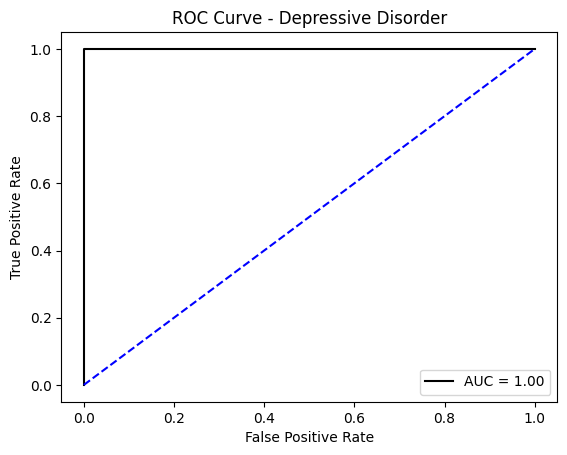

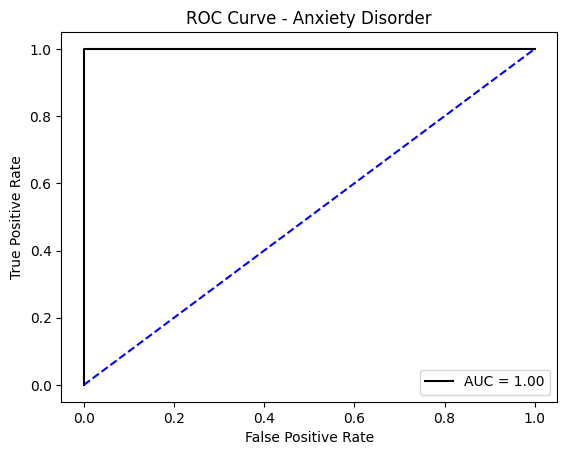

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,  # Ensure this is imported
)
import matplotlib.pyplot as plt
# Separate features (X) and target variables (y)
X = data.drop(["Depressive Disorder", "Anxiety Disorder"], axis=1)
y_depressive = data["Depressive Disorder"]
y_anxiety = data["Anxiety Disorder"]

# One-hot encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

# Splitting data into training and testing sets for each target variable
X_train_dep, X_test_dep, y_train_dep, y_test_dep = train_test_split(
    X, y_depressive, test_size=0.3, random_state=42
)
X_train_anx, X_test_anx, y_train_anx, y_test_anx = train_test_split(
    X, y_anxiety, test_size=0.3, random_state=42
)

# Initialize the Random Forest classifier
rf_model_dep = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_anx = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the models
rf_model_dep.fit(X_train_dep, y_train_dep)
rf_model_anx.fit(X_train_anx, y_train_anx)

# Make predictions
y_pred_dep = rf_model_dep.predict(X_test_dep)
y_pred_anx = rf_model_anx.predict(X_test_anx)

# Evaluate the models
print("Depressive Disorder Evaluation:")
print("Accuracy:", accuracy_score(y_test_dep, y_pred_dep))
print("Precision:", precision_score(y_test_dep, y_pred_dep, zero_division=0))
print("Recall:", recall_score(y_test_dep, y_pred_dep, zero_division=0))
print("F1 Score:", f1_score(y_test_dep, y_pred_dep, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test_dep, y_pred_dep))
print("\nClassification Report:\n", classification_report(y_test_dep, y_pred_dep, zero_division=0))

print("\nAnxiety Disorder Evaluation:")
print("Accuracy:", accuracy_score(y_test_anx, y_pred_anx))
print("Precision:", precision_score(y_test_anx, y_pred_anx, zero_division=0))
print("Recall:", recall_score(y_test_anx, y_pred_anx, zero_division=0))
print("F1 Score:", f1_score(y_test_anx, y_pred_anx, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test_anx, y_pred_anx))
print("\nClassification Report:\n", classification_report(y_test_anx, y_pred_anx, zero_division=0))

# Plotting ROC Curve and calculating AUC for Depressive Disorder
fpr_dep, tpr_dep, _ = roc_curve(y_test_dep, rf_model_dep.predict_proba(X_test_dep)[:, 1])
auc_dep = roc_auc_score(y_test_dep, rf_model_dep.predict_proba(X_test_dep)[:, 1])

plt.figure()
plt.plot(fpr_dep, tpr_dep, color="black", label=f"AUC = {auc_dep:.2f}")
plt.plot([0, 1], [0, 1], color="blue", linestyle="--")
plt.title("ROC Curve - Depressive Disorder")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plotting ROC Curve and calculating AUC for Anxiety Disorder
fpr_anx, tpr_anx, _ = roc_curve(y_test_anx, rf_model_anx.predict_proba(X_test_anx)[:, 1])
auc_anx = roc_auc_score(y_test_anx, rf_model_anx.predict_proba(X_test_anx)[:, 1])

plt.figure()
plt.plot(fpr_anx, tpr_anx, color="black", label=f"AUC = {auc_anx:.2f}")
plt.plot([0, 1], [0, 1], color="blue", linestyle="--")
plt.title("ROC Curve - Anxiety Disorder")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

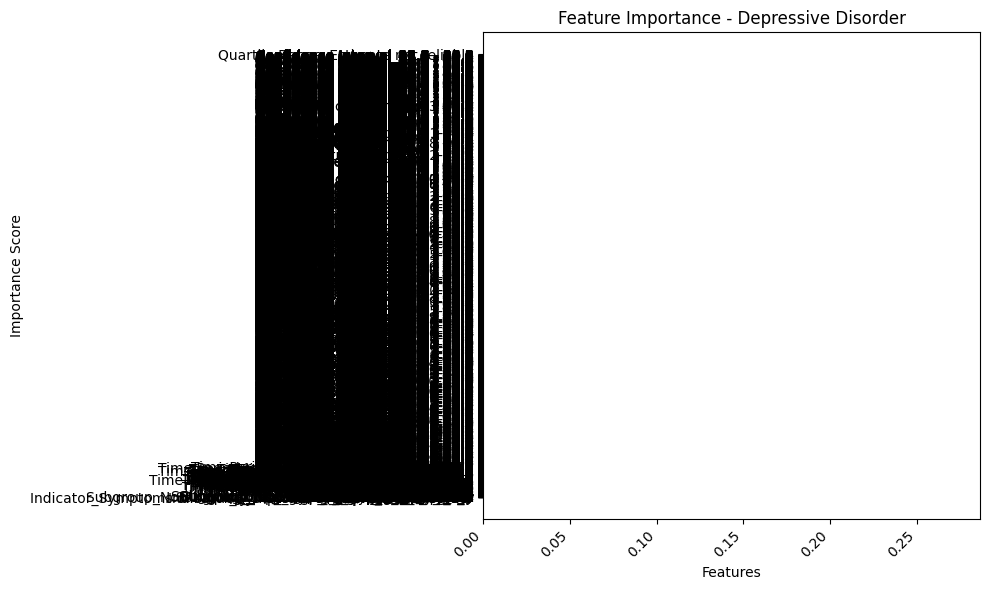

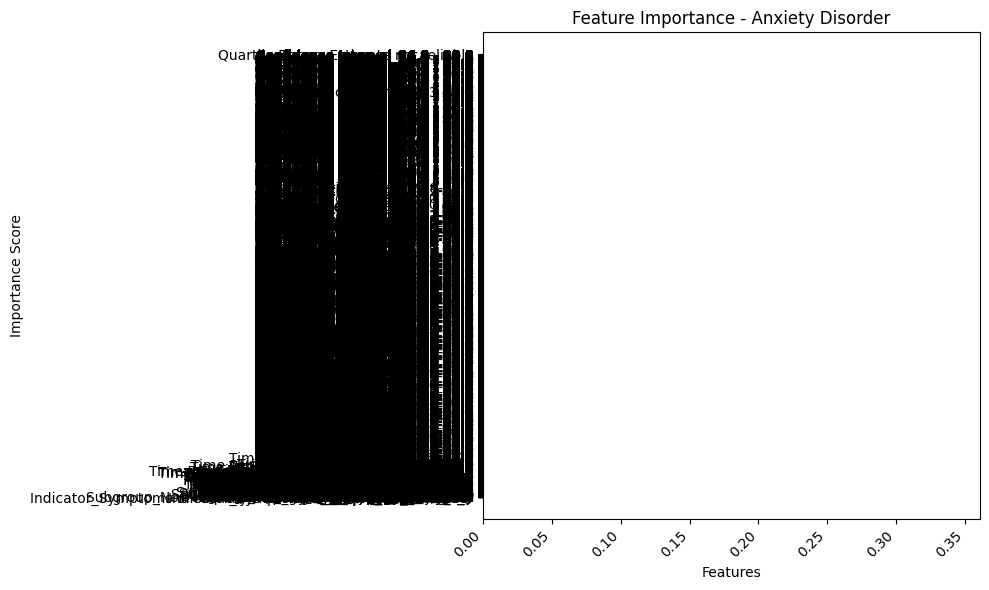

Most influential feature for Depressive Disorder: Indicator_Symptoms of Anxiety Disorder or Depressive Disorder with importance score 0.27
Most influential feature for Anxiety Disorder: Anxity Disorder with importance score 0.34


In [ ]:
# Calculate feature importance for Depressive Disorder
importance_dep = rf_model_dep.feature_importances_
features = X.columns  # Column names of the dataset

# Create a DataFrame for better visualization
importance_df_dep = pd.DataFrame({
    'Feature': features,
    'Importance': importance_dep
}).sort_values(by='Importance', ascending=False)

# Calculate feature importance for Anxiety Disorder
importance_anx = rf_model_anx.feature_importances_

# Create a DataFrame for better visualization
importance_df_anx = pd.DataFrame({
    'Feature': features,
    'Importance': importance_anx
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances for Depressive Disorder
plt.figure(figsize=(10, 6))
plt.barh(importance_df_dep['Feature'], importance_df_dep['Importance'], color='blue')
plt.title("Feature Importance - Depressive Disorder")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot Feature Importances for Anxiety Disorder
plt.figure(figsize=(10, 6))
plt.barh(importance_df_anx['Feature'], importance_df_anx['Importance'], color='green')
plt.title("Feature Importance - Anxiety Disorder")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Identify the most influential feature
most_influential_dep = importance_df_dep.iloc[0]
most_influential_anx = importance_df_anx.iloc[0]

print(f"Most influential feature for Depressive Disorder: {most_influential_dep['Feature']} "
      f"with importance score {most_influential_dep['Importance']:.2f}")

print(f"Most influential feature for Anxiety Disorder: {most_influential_anx['Feature']} "
      f"with importance score {most_influential_anx['Importance']:.2f}")


Decision Tree

As decision Tree is an analysis technique that is used to perform both classification and regression tasks providing a tree like structure plot with some nodes and branches, it is extremely easy to understand the insights and patterns that are resulted. We have chosen decision tree as our second model. We split the dataset with 30% testing data and 70% training data as well.
The Below image indicates that the accuracy of the decision tree for depressive disorder is 68% which is a good indicator that our model is performing well. Other evaluation metrics such as Precision, Recall and F1 score have also been calculated for each disorder. For the depressive order class, we got a precision value of 0.68 which suggests that the model is correctly predicting the positive class. The recall value of 1.00 suggests that the recall value is extremely high and indicates that the random forest is identifying all the actual instances of the depressive order successfully. As the precision and recall value is high, the F1- score has also resulted in a high value if 0.81. We have also calculated AUC score and ROC curve, for depressive disorder, AUC score of 0.50 identifies that the model is performing moderate in predicting depressive order and can perform more well.


Depressive Disorder Evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[1667    0]
 [   0 3301]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1667
           1       1.00      1.00      1.00      3301

    accuracy                           1.00      4968
   macro avg       1.00      1.00      1.00      4968
weighted avg       1.00      1.00      1.00      4968


Anxiety Disorder Evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[1711    0]
 [   0 3257]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1711
           1       1.00      1.00      1.00      3257

    accuracy                           1.00      4968
   macro avg       1.00      1.00      1.00      4968
weighted avg       1.00      1.00      1.00      4968



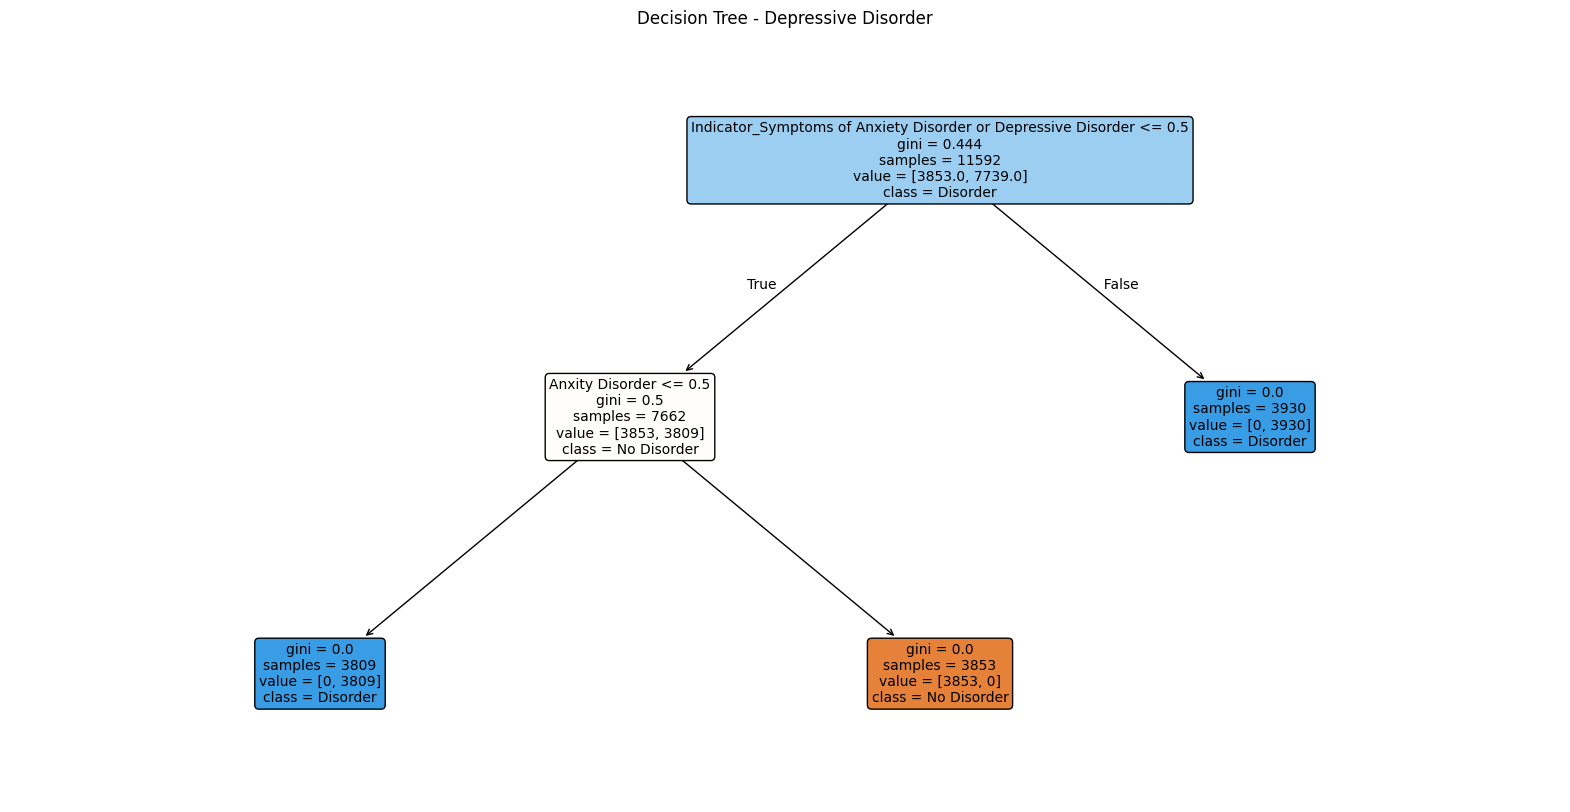

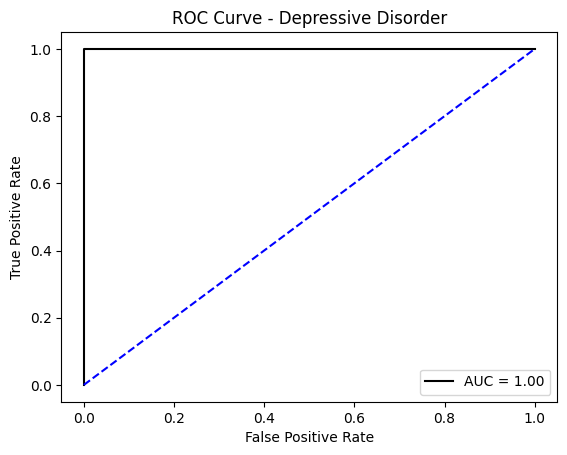

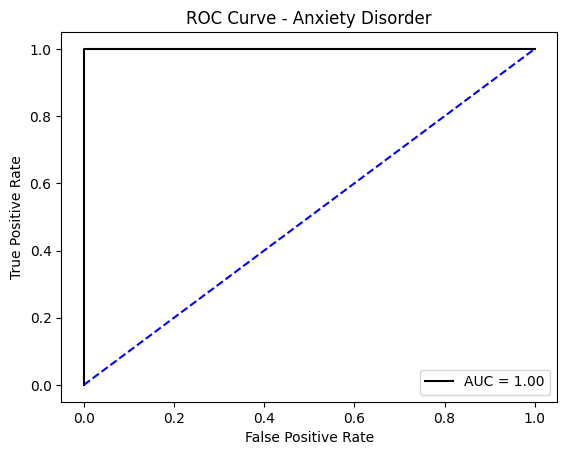

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)
import matplotlib.pyplot as plt

# Assuming 'data' is a preloaded pandas DataFrame

# Separate features (X) and target variables (y)
X = data.drop(["Depressive Disorder", "Anxiety Disorder"], axis=1)
y_depressive = data["Depressive Disorder"]
y_anxiety = data["Anxiety Disorder"]

# One-hot encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

# Splitting data into training and testing sets for each target variable (70% train, 30% test)
X_train_dep, X_test_dep, y_train_dep, y_test_dep = train_test_split(
    X, y_depressive, test_size=0.3, random_state=42
)
X_train_anx, X_test_anx, y_train_anx, y_test_anx = train_test_split(
    X, y_anxiety, test_size=0.3, random_state=42
)

# Initialize the Decision Tree classifier
dt_model_dep = DecisionTreeClassifier(random_state=42)
dt_model_anx = DecisionTreeClassifier(random_state=42)

# Train the models
dt_model_dep.fit(X_train_dep, y_train_dep)
dt_model_anx.fit(X_train_anx, y_train_anx)

# Make predictions
y_pred_dep = dt_model_dep.predict(X_test_dep)
y_pred_anx = dt_model_anx.predict(X_test_anx)

# Evaluate the models
print("Depressive Disorder Evaluation:")
print("Accuracy:", accuracy_score(y_test_dep, y_pred_dep))
print("Precision:", precision_score(y_test_dep, y_pred_dep, zero_division=0))
print("Recall:", recall_score(y_test_dep, y_pred_dep, zero_division=0))
print("F1 Score:", f1_score(y_test_dep, y_pred_dep, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test_dep, y_pred_dep))
print("\nClassification Report:\n", classification_report(y_test_dep, y_pred_dep, zero_division=0))

print("\nAnxiety Disorder Evaluation:")
print("Accuracy:", accuracy_score(y_test_anx, y_pred_anx))
print("Precision:", precision_score(y_test_anx, y_pred_anx, zero_division=0))
print("Recall:", recall_score(y_test_anx, y_pred_anx, zero_division=0))
print("F1 Score:", f1_score(y_test_anx, y_pred_anx, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test_anx, y_pred_anx))
print("\nClassification Report:\n", classification_report(y_test_anx, y_pred_anx, zero_division=0))

# Plot the Decision Tree for Depressive Disorder
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model_dep,
    feature_names=X.columns,
    class_names=["No Disorder", "Disorder"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree - Depressive Disorder")
plt.show()

# Plotting ROC Curve and calculating AUC for Depressive Disorder
fpr_dep, tpr_dep, _ = roc_curve(y_test_dep, dt_model_dep.predict_proba(X_test_dep)[:, 1])
auc_dep = roc_auc_score(y_test_dep, dt_model_dep.predict_proba(X_test_dep)[:, 1])

plt.figure()
plt.plot(fpr_dep, tpr_dep, color="black", label=f"AUC = {auc_dep:.2f}")
plt.plot([0, 1], [0, 1], color="blue", linestyle="--")
plt.title("ROC Curve - Depressive Disorder")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plotting ROC Curve and calculating AUC for Anxiety Disorder
fpr_anx, tpr_anx, _ = roc_curve(y_test_anx, dt_model_anx.predict_proba(X_test_anx)[:, 1])
auc_anx = roc_auc_score(y_test_anx, dt_model_anx.predict_proba(X_test_anx)[:, 1])

plt.figure()
plt.plot(fpr_anx, tpr_anx, color="black", label=f"AUC = {auc_anx:.2f}")
plt.plot([0, 1], [0, 1], color="blue", linestyle="--")
plt.title("ROC Curve - Anxiety Disorder")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


**Predicting the future trends of anxiety and depression disorder among people who are over the age of 50 years in the United States using time-series forecasting model.**

By applying LSTM neural network model, we had predicted the future trends of anxiety and depressive disorder among people who are over the age of 50. For this research question, we have firstly filtered our dataset by ‘Subgroup’ containing 50-59 years, 60-69 years, 70-79 years, and 80 years and above as seen in the below figure.


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: nan - val_loss: nan
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: nan - val_loss: nan
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: nan - val_loss: nan
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: nan - val_loss: nan
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: nan - val_loss: nan
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: nan - val_loss: nan
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: nan - val_loss: nan
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: nan - val_loss: nan
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: nan - val_loss: nan
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: nan - val_loss: nan
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: nan - val_loss: nan
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: nan - val_loss: nan
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: nan - val_loss: nan
Epoch 

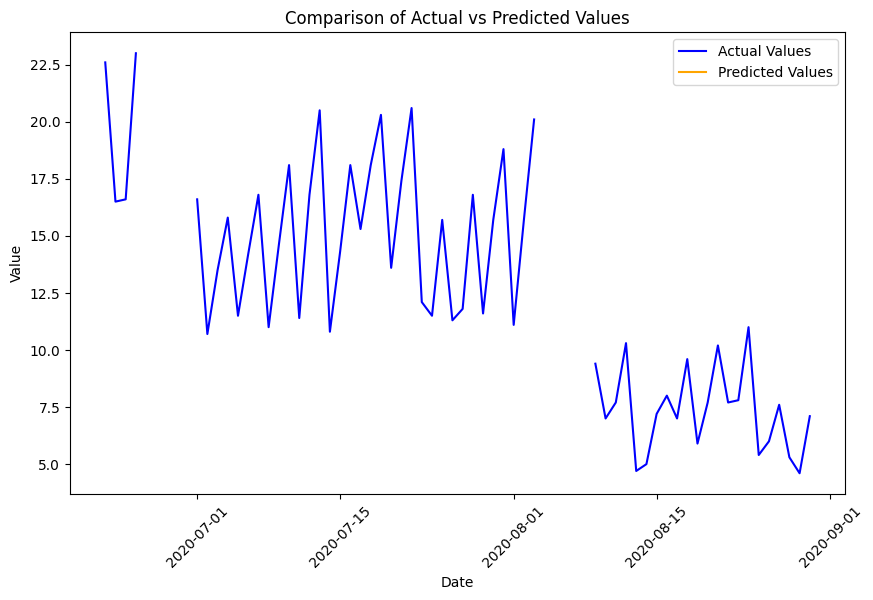

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


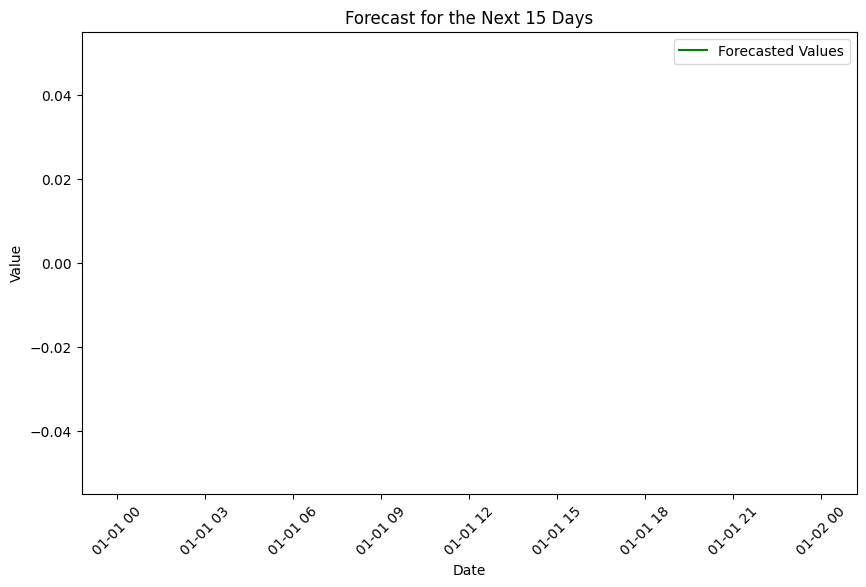

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Step 1: Load and filter the dataset
df = pd.read_csv('/content/Indicators_of_Anxiety_or_Depression_Based_on_Reported_Frequency_of_Symptoms_During_Last_7_Days.csv')

# Filter dataset for individuals aged 50 and above
age_groups = ['50-59 years', '60-69 years', '70-79 years', '80 years and above']
df_filtered = df[df['Subgroup'].isin(age_groups)].reset_index(drop=True)

# Ensure there is a 'Date' column or create one
if 'Date' in df_filtered.columns:
    df_filtered['Date'] = pd.to_datetime(df_filtered['Date'])
else:
    # Generate synthetic dates if 'Date' column is missing
    df_filtered['Date'] = pd.date_range(start='2020-01-01', periods=len(df_filtered), freq='D')

# Step 2: Normalize the 'Value' column
scaler = MinMaxScaler(feature_range=(0, 1))
df_filtered['Value_normalized'] = scaler.fit_transform(df_filtered[['Value']])

# Step 3: Prepare the data for the LSTM model
sequence_length = 12  # Number of past data points used to predict the next one
data = df_filtered['Value_normalized'].values
X, y = [], []

for i in range(len(data) - sequence_length):
    X.append(data[i:i+sequence_length])
    y.append(data[i+sequence_length])

X = np.array(X)
y = np.array(y)

# Reshape X for LSTM model
X = X.reshape((X.shape[0], X.shape[1], 1))

# Step 4: Split data into training and testing sets
train_size = int(len(X) * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

dates_test = df_filtered['Date'].iloc[train_size + sequence_length:].reset_index(drop=True)

# Step 5: Build the LSTM model
model = Sequential()
model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Step 6: Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 7: Evaluate the model and visualize results
predicted_values = model.predict(X_test)
predicted_values = scaler.inverse_transform(predicted_values.reshape(-1, 1))
actual_values = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot actual vs. predicted values with dates
plt.figure(figsize=(10, 6))
plt.plot(dates_test, actual_values, label='Actual Values', color='blue')
plt.plot(dates_test, predicted_values, label='Predicted Values', color='orange')
plt.title('Comparison of Actual vs Predicted Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Step 8: Forecast for the next 15 days
last_sequence = data[-sequence_length:]  # Get the last sequence from the dataset
forecast = []

for _ in range(15):  # Predict the next 15 days
    pred = model.predict(last_sequence.reshape(1, sequence_length, 1))
    forecast.append(pred[0, 0])
    last_sequence = np.append(last_sequence[1:], pred[0, 0])  # Update sequence with the prediction

# Rescale forecasted values back to original scale
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

# Generate future dates for the forecast
last_date = dates_test.iloc[-1]
future_dates = [last_date + pd.Timedelta(days=i + 1) for i in range(15)]

# Plot forecasted values with future dates
plt.figure(figsize=(10, 6))
plt.plot(future_dates, forecast, label='Forecasted Values', color='green')
plt.title('Forecast for the Next 15 Days')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.show()
